# Sun–shade linear spectral unmixing

Standalone workflow for an ENVI hyperspectral image (`.bsq` + `.hdr`).

The workflow uses **NDCSI-based automatic endmember selection** and a **single two-endmember linear spectral model** for all vegetation:

1. read wavelengths and reflectance data;
2. define the forest/vegetation analysis domain by means of a forest mask (Optional) or an NDVI threshold;
3. calculate NDCSI;
4. select shaded and sunlit support pixels from the lower and upper NDCSI tails;
5. derive one median shaded and one median sunlit spectral endmember;
6. project each vegetation-pixel spectrum onto the shade-to-sun mixing line;
7. export `f_sun` and spectral-fit RMSE, then inspect the main diagnostics.

`f_sun = 0` corresponds to the shaded endmember and `f_sun = 1` to the sunlit endmember. It is a **spectral mixing coordinate**, not an exact physical sunlit fraction unless validated against independent sun/shade reference data.

## Settings

Adjust the input paths and, if needed, the small set of tuning parameters below. If no forest-fraction raster is supplied, NDVI is used only as a fallback vegetation selector.

In [1]:
from pathlib import Path
import re
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import Window
from shapely.geometry import Point

# --- Input / output -----------------------------------------------------------
BSQ_PATH = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/20230618-KRA-1057-1111-MOSAIC-0350-L1-L4-DUAL-rect_img_atm_pol_georect_subset_warped_spa_sub_core25_spec_sub_372_1000_357_bands.bsq")
HDR_PATH = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/20230618-KRA-1057-1111-MOSAIC-0350-L1-L4-DUAL-rect_img_atm_pol_georect_subset_warped_spa_sub_core25_spec_sub_372_1000_357_bands.hdr")
OUT_DIR = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/output_sun_shade")

# Optional forest-fraction raster (0..1) on exactly the same grid as the BSQ.
# Leave as None to use NDVI as the vegetation mask.
FOREST_FRACTION_PATH = None
FOREST_FRACTION_MIN = 0.50
VEG_NDVI_MIN = 0.50

# --- NDCSI / endmember selection ---------------------------------------------
NDCSI_NORMALIZATION_QUANTILES = (0.01, 0.99)
SHADE_NDCSI_QUANTILE = 0.15
SUN_NDCSI_QUANTILE = 0.85
ENDMEMBER_SUPPORT_SIZE = 40
MIN_SUPPORT_REQUIRED = 20
MIN_SPACING_PIXELS = 2
RED_EDGE_SEARCH_RANGE = (680.0, 750.0)
RED_EDGE_HALF_WIDTH_NM = 2.5
MAX_RED_EDGE_SAMPLES = 3000
RANDOM_SEED = 42

# --- Spectral processing ------------------------------------------------------
RED_RANGE = (650.0, 680.0)
NIR_RANGE = (780.0, 900.0)
UNMIXING_RANGE = (400.0, 1100.0)
EXCLUDE_RANGES = ()
BLOCK_ROWS = 64
REFLECTANCE_SCALE = 10000.0
NODATA_VALUE = None
VALID_REFLECTANCE_RANGE = (0.0, 1.0)
OUTPUT_NODATA = -9999.0
RMSE_DISPLAY_MAX = None

# --- Shared figure style ------------------------------------------------------
SUN_COLOR = "#D98E04"
SHADE_COLOR = "#2F6B8A"
MAP_CMAP = "viridis"
FIG_DPI = 180
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.grid": False,
    "legend.frameon": False,
})

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")

Output directory: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade


## 1. Read wavelengths and reflectance data

Read ENVI wavelengths, verify the raster, and define the small reusable I/O helpers used below.

In [2]:
def read_envi_wavelengths(hdr_path):
    """Read ENVI wavelength values and return nanometres."""
    try:
        text = Path(hdr_path).read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = Path(hdr_path).read_text(encoding="latin-1")

    match = re.search(r"(?is)\bwavelength\s*=\s*\{(.*?)\}", text)
    if match is None:
        raise ValueError(f"No wavelength field found in {hdr_path}")

    wavelengths = np.asarray([
        float(v.strip())
        for v in match.group(1).replace("\n", " ").split(",")
        if v.strip()
    ], dtype="float64")

    units_match = re.search(r"(?im)^\s*wavelength\s+units\s*=\s*([^\r\n]+)", text)
    units = units_match.group(1).strip().strip("{} ") if units_match else ""
    if "micro" in units.lower() or "µm" in units.lower() or units.lower() == "um":
        wavelengths *= 1000.0
    elif not units and np.nanmedian(wavelengths) < 10:
        wavelengths *= 1000.0

    bands_match = re.search(r"(?im)^\s*bands\s*=\s*(\d+)", text)
    return wavelengths, int(bands_match.group(1)) if bands_match else None


def band_indices(spectral_range):
    low, high = spectral_range
    idx = np.flatnonzero((wavelengths >= low) & (wavelengths <= high))
    if idx.size == 0:
        idx = np.array([np.argmin(np.abs(wavelengths - (low + high) / 2))])
    return idx


def scaled_reflectance(raw, src_nodata=None):
    raw = np.asarray(raw)
    arr = raw.astype("float32", copy=True)
    invalid = ~np.isfinite(arr)
    nodata = NODATA_VALUE if NODATA_VALUE is not None else src_nodata
    if nodata is not None:
        invalid |= raw == nodata
    arr /= REFLECTANCE_SCALE
    lo, hi = VALID_REFLECTANCE_RANGE
    invalid |= (arr < lo) | (arr > hi)
    arr[invalid] = np.nan
    return arr


def mean_reflectance(spectral_range):
    idx = band_indices(spectral_range)
    with rasterio.open(BSQ_PATH) as src:
        arr = scaled_reflectance(src.read((idx + 1).tolist()), src.nodata)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmean(arr, axis=0).astype("float32")


def sample_spectra(rows, cols):
    rows, cols = np.asarray(rows, int), np.asarray(cols, int)
    if rows.size == 0:
        return np.empty((0, len(wavelengths)), dtype="float32")
    with rasterio.open(BSQ_PATH) as src:
        xs, ys = rasterio.transform.xy(src.transform, rows, cols, offset="center")
        raw = np.asarray(list(src.sample(zip(xs, ys))), dtype="float32")
        return scaled_reflectance(raw, src.nodata)


def spectral_stats(spectra, label):
    spectra = spectra[np.isfinite(spectra).mean(axis=1) >= 0.98]
    if len(spectra) < MIN_SUPPORT_REQUIRED:
        raise ValueError(f"Only {len(spectra)} valid spectra remain for {label}")
    return {
        "median": np.nanmedian(spectra, axis=0).astype("float32"),
        "p10": np.nanpercentile(spectra, 10, axis=0).astype("float32"),
        "p90": np.nanpercentile(spectra, 90, axis=0).astype("float32"),
        "n": len(spectra),
    }


def load_forest_fraction(path):
    with rasterio.open(BSQ_PATH) as ref, rasterio.open(path) as src:
        if src.crs != ref.crs or (src.height, src.width) != (ref.height, ref.width):
            raise ValueError("Forest raster CRS or shape does not match the hyperspectral raster")
        if not src.transform.almost_equals(ref.transform):
            raise ValueError("Forest raster grid does not match the hyperspectral raster")
        return src.read(1, masked=True).filled(np.nan).astype("float32")


def write_tif(filename, values, description):
    with rasterio.open(BSQ_PATH) as src:
        profile = src.profile.copy()
        profile.update(
            driver="GTiff", count=1, dtype="float32", nodata=OUTPUT_NODATA,
            compress="deflate",
        )
    data = np.where(np.isfinite(values), values, OUTPUT_NODATA).astype("float32")
    out_path = OUT_DIR / filename
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data, 1)
        dst.set_band_description(1, description)
    return out_path


wavelengths, hdr_band_count = read_envi_wavelengths(HDR_PATH)
with rasterio.open(BSQ_PATH) as src:
    raster_shape = (src.height, src.width)
    raster_band_count = src.count
    raster_crs = src.crs
    raster_resolution = src.res

if len(wavelengths) != raster_band_count:
    raise ValueError(f"Header has {len(wavelengths)} wavelengths; raster has {raster_band_count} bands")
if hdr_band_count is not None and hdr_band_count != raster_band_count:
    raise ValueError(f"Header says {hdr_band_count} bands; raster has {raster_band_count}")

print(
    f"Raster: {raster_shape[1]} x {raster_shape[0]} pixels | {raster_band_count} bands | "
    f"{wavelengths.min():.1f}-{wavelengths.max():.1f} nm | resolution {raster_resolution} | CRS {raster_crs}"
)

Raster: 700 x 700 pixels | 357 bands | 373.4-1000.2 nm | resolution (0.5, 0.5) | CRS EPSG:32632


## 2. Define the vegetation domain and calculate NDVI

If a forest-fraction raster is supplied, it defines the analysis domain. Otherwise `NDVI >= VEG_NDVI_MIN` is used as a fallback vegetation mask.

In [3]:
red = mean_reflectance(RED_RANGE)
nir = mean_reflectance(NIR_RANGE)

den = nir + red
ndvi = np.full(raster_shape, np.nan, dtype="float32")
valid = np.isfinite(red) & np.isfinite(nir) & (np.abs(den) > 1e-8)
ndvi[valid] = (nir[valid] - red[valid]) / den[valid]

if FOREST_FRACTION_PATH is None:
    forest_fraction = None
    analysis_mask = np.isfinite(ndvi) & (ndvi >= VEG_NDVI_MIN)
    mask_description = f"NDVI >= {VEG_NDVI_MIN:g} (fallback)"
else:
    forest_fraction = load_forest_fraction(FOREST_FRACTION_PATH)
    analysis_mask = (
        np.isfinite(forest_fraction)
        & (forest_fraction >= FOREST_FRACTION_MIN)
        & np.isfinite(ndvi)
    )
    mask_description = f"forest fraction >= {FOREST_FRACTION_MIN:g}"

if analysis_mask.sum() < 2 * MIN_SUPPORT_REQUIRED:
    raise ValueError(f"Only {analysis_mask.sum()} pixels remain in the analysis domain")

write_tif("NDVI.tif", ndvi, "NDVI")
print(f"Analysis domain: {mask_description} | {analysis_mask.sum():,} pixels")

Analysis domain: NDVI >= 0.5 (fallback) | 488,080 pixels


## 3. Calculate NDCSI

Estimate the scene red-edge wavelength from vegetation spectra, robustly normalize red-edge reflectance within the analysis domain, and calculate:

`NDCSI = NDVI x normalized red-edge reflectance`

Higher NDCSI is treated as relatively more sunlit vegetation; lower NDCSI as relatively more shaded vegetation.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
rows, cols = np.nonzero(analysis_mask)
if len(rows) > MAX_RED_EDGE_SAMPLES:
    pick = rng.choice(len(rows), MAX_RED_EDGE_SAMPLES, replace=False)
    rows, cols = rows[pick], cols[pick]

spectra = sample_spectra(rows, cols)
search_idx = band_indices(RED_EDGE_SEARCH_RANGE)
median_spectrum = np.nanmedian(spectra[:, search_idx], axis=0)
search_wavelengths = wavelengths[search_idx]
finite = np.isfinite(median_spectrum) & np.isfinite(search_wavelengths)
if finite.sum() < 3:
    raise ValueError("Too few valid bands to estimate the red edge")

red_edge_nm = float(search_wavelengths[finite][np.nanargmax(
    np.gradient(median_spectrum[finite], search_wavelengths[finite])
)])
rho_re = mean_reflectance((
    red_edge_nm - RED_EDGE_HALF_WIDTH_NM,
    red_edge_nm + RED_EDGE_HALF_WIDTH_NM,
))

q_low, q_high = NDCSI_NORMALIZATION_QUANTILES
re_values = rho_re[analysis_mask & np.isfinite(rho_re)]
re_min, re_max = np.quantile(re_values, (q_low, q_high))
if not np.isfinite(re_min + re_max) or re_max <= re_min:
    raise ValueError("Invalid red-edge reflectance range for NDCSI normalization")

ndcsi = ndvi * (rho_re - re_min) / (re_max - re_min)
ndcsi = np.clip(ndcsi, 0, 1).astype("float32")
ndcsi[~analysis_mask] = np.nan

write_tif("NDCSI.tif", ndcsi, "NDCSI")
print(
    f"Red edge: {red_edge_nm:.2f} nm | "
    f"NDCSI normalization q{q_low:.2f}-q{q_high:.2f}: {re_min:.4f}-{re_max:.4f}"
)

Red edge: 732.59 nm | NDCSI normalization q0.01-q0.99: 0.0311-0.3747


## 4. Select shaded and sunlit support pixels

Use the lower and upper NDCSI tails as candidate pools, then retain spatially separated extreme pixels. These are support samples for endmember construction, not independent sun/shade truth.

Selected 40 shaded + 40 sunlit support pixels


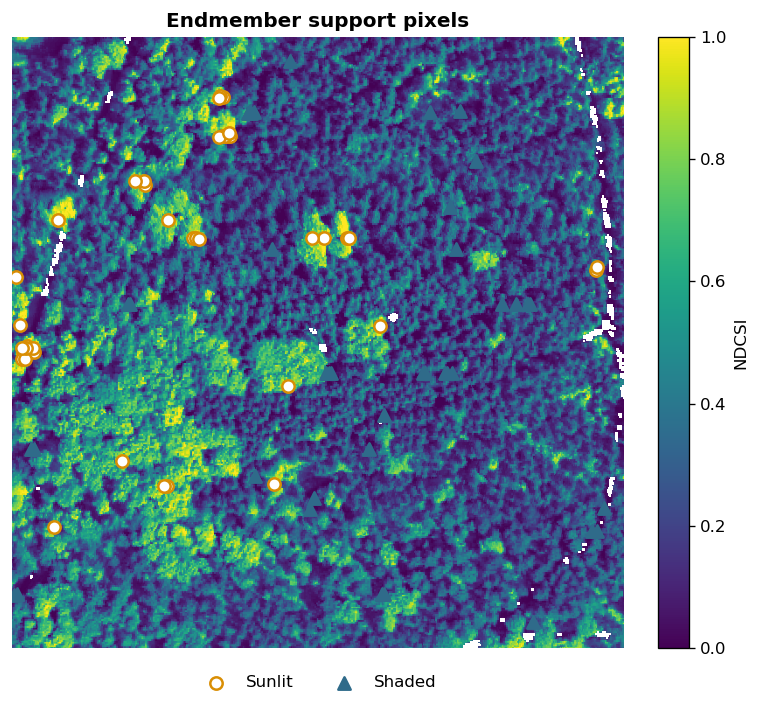

In [5]:
def select_support(candidate_mask, label):
    rows, cols = np.nonzero(candidate_mask)
    values = ndcsi[rows, cols]
    order = np.argsort(values)
    if label == "sunlit":
        order = order[::-1]

    def choose(spacing):
        selected = []
        for row, col, value in zip(rows[order], cols[order], values[order]):
            if spacing and any(
                max(abs(int(row) - r0), abs(int(col) - c0)) <= spacing
                for r0, c0, _ in selected
            ):
                continue
            selected.append((int(row), int(col), float(value)))
            if len(selected) == ENDMEMBER_SUPPORT_SIZE:
                break
        return selected

    selected = choose(MIN_SPACING_PIXELS)
    if len(selected) < MIN_SUPPORT_REQUIRED and MIN_SPACING_PIXELS > 0:
        selected = choose(0)
    if len(selected) < MIN_SUPPORT_REQUIRED:
        raise ValueError(f"Only {len(selected)} {label} support pixels are available")
    return selected


values = ndcsi[analysis_mask & np.isfinite(ndcsi)]
shade_threshold = float(np.quantile(values, SHADE_NDCSI_QUANTILE))
sun_threshold = float(np.quantile(values, SUN_NDCSI_QUANTILE))
shade_pool = analysis_mask & np.isfinite(ndcsi) & (ndcsi <= shade_threshold)
sun_pool = analysis_mask & np.isfinite(ndcsi) & (ndcsi >= sun_threshold)

shade_support = select_support(shade_pool, "shaded")
sun_support = select_support(sun_pool, "sunlit")
print(f"Selected {len(shade_support)} shaded + {len(sun_support)} sunlit support pixels")

# Save support points for spatial inspection in GIS.
records = []
with rasterio.open(BSQ_PATH) as src:
    for label, support in (("shaded", shade_support), ("sunlit", sun_support)):
        for rank, (row, col, value) in enumerate(support, 1):
            x, y = rasterio.transform.xy(src.transform, row, col, offset="center")
            records.append({
                "class": label, "rank": rank, "row": row, "col": col,
                "ndcsi": value, "ndvi": float(ndvi[row, col]),
                "geometry": Point(float(x), float(y)),
            })
    support_crs = src.crs

support_points = gpd.GeoDataFrame(records, geometry="geometry", crs=support_crs)
gpkg_path = OUT_DIR / "endmember_support_pixels.gpkg"
if gpkg_path.exists():
    gpkg_path.unlink()
support_points.to_file(gpkg_path, layer="endmember_pixels", driver="GPKG")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ndcsi, cmap=MAP_CMAP, vmin=0, vmax=1)
for label, support, marker, color, filled in (
    ("Sunlit", sun_support, "o", SUN_COLOR, False),
    ("Shaded", shade_support, "^", SHADE_COLOR, True),
):
    ax.scatter(
        [p[1] for p in support], [p[0] for p in support],
        s=55, marker=marker,
        facecolors=color if filled else "white", edgecolors=color, linewidths=1.5,
        label=label,
    )
ax.set_title("Endmember support pixels")
ax.axis("off")
fig.colorbar(im, ax=ax, label="NDCSI", fraction=0.046, pad=0.04)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "endmember_support_pixels.png", bbox_inches="tight")
plt.show()

## 5. Build shaded and sunlit spectral endmembers

Use the median spectrum of each support set as the shaded or sunlit endmember. The 10th–90th percentile envelopes are shown only as a QC diagnostic.

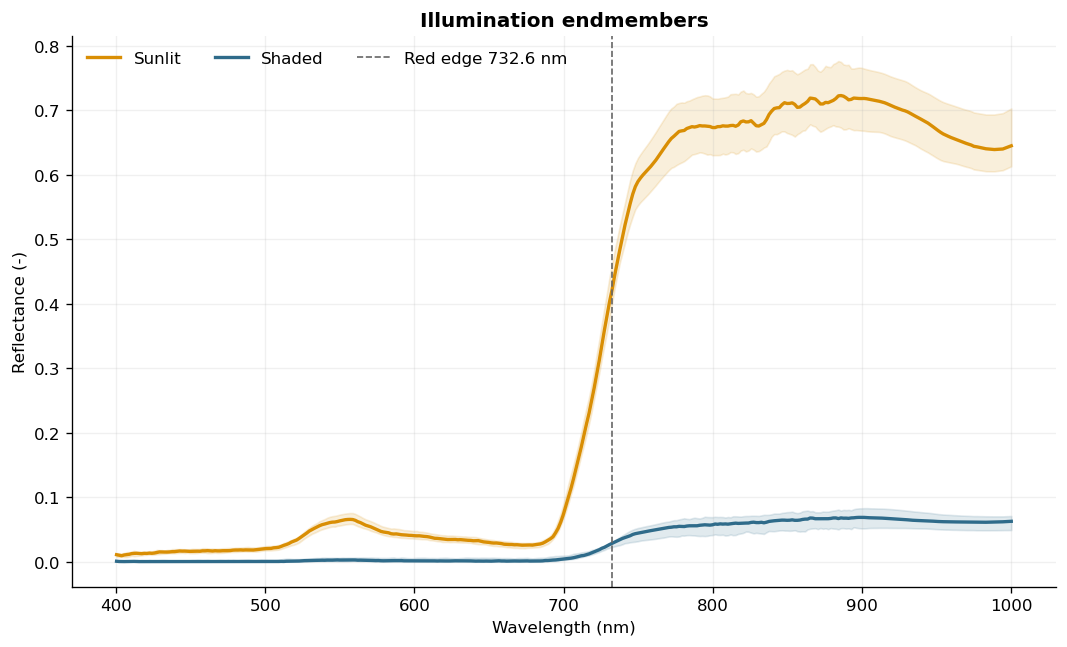

In [6]:
endmembers = {}
stats = {}
for label, support in (("shaded", shade_support), ("sunlit", sun_support)):
    rows = [p[0] for p in support]
    cols = [p[1] for p in support]
    stats[label] = spectral_stats(sample_spectra(rows, cols), label)
    endmembers[label] = stats[label]["median"]

shade_endmember = endmembers["shaded"]
sun_endmember = endmembers["sunlit"]

np.savez_compressed(
    OUT_DIR / "sun_shade_endmembers.npz",
    wavelengths=wavelengths.astype("float32"),
    shaded=shade_endmember,
    sunlit=sun_endmember,
    shaded_p10=stats["shaded"]["p10"],
    shaded_p90=stats["shaded"]["p90"],
    sunlit_p10=stats["sunlit"]["p10"],
    sunlit_p90=stats["sunlit"]["p90"],
    red_edge_wavelength_nm=np.asarray([red_edge_nm], dtype="float32"),
    shade_ndcsi_threshold=np.asarray([shade_threshold], dtype="float32"),
    sun_ndcsi_threshold=np.asarray([sun_threshold], dtype="float32"),
)

keep = band_indices(UNMIXING_RANGE)
fig, ax = plt.subplots(figsize=(9, 5.5))
for label, color in (("Sunlit", SUN_COLOR), ("Shaded", SHADE_COLOR)):
    s = stats[label.lower()]
    ax.plot(wavelengths[keep], s["median"][keep], color=color, linewidth=2, label=label)
    ax.fill_between(
        wavelengths[keep], s["p10"][keep], s["p90"][keep],
        color=color, alpha=0.14,
    )
ax.axvline(red_edge_nm, color="0.4", linestyle="--", linewidth=1, label=f"Red edge {red_edge_nm:.1f} nm")
ax.set(title="Illumination endmembers", xlabel="Wavelength (nm)", ylabel="Reflectance (-)")
ax.grid(alpha=0.18)
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(OUT_DIR / "endmember_spectra.png", bbox_inches="tight")
plt.show()

## 6. Estimate `f_sun` and spectral-fit RMSE

Project every vegetation spectrum onto the line from the shaded to the sunlit endmember. Values are clipped to `[0, 1]`; RMSE measures the residual spectral mismatch.

In [7]:
keep = (wavelengths >= UNMIXING_RANGE[0]) & (wavelengths <= UNMIXING_RANGE[1])
for low, high in EXCLUDE_RANGES:
    keep &= ~((wavelengths >= low) & (wavelengths <= high))
band_idx = np.flatnonzero(keep)

sun = sun_endmember[band_idx].astype("float64")
shade = shade_endmember[band_idx].astype("float64")
finite = np.isfinite(sun) & np.isfinite(shade)
band_idx, sun, shade = band_idx[finite], sun[finite], shade[finite]

if len(band_idx) < 2:
    raise ValueError("Too few finite wavelength bands remain for unmixing")
direction = sun - shade
denom = float(direction @ direction)
if not np.isfinite(denom) or denom <= 1e-12:
    raise ValueError("Sunlit and shaded endmembers are spectrally indistinguishable")

f_sun = np.full(raster_shape, np.nan, dtype="float32")
rmse = np.full(raster_shape, np.nan, dtype="float32")

with rasterio.open(BSQ_PATH) as src:
    raster_bands = (band_idx + 1).tolist()
    for y0 in range(0, raster_shape[0], BLOCK_ROWS):
        y1 = min(raster_shape[0], y0 + BLOCK_ROWS)
        block = scaled_reflectance(
            src.read(raster_bands, window=Window(0, y0, raster_shape[1], y1 - y0)),
            src.nodata,
        ).astype("float64")
        Y = block.reshape(len(band_idx), -1)
        valid = np.all(np.isfinite(Y), axis=0) & analysis_mask[y0:y1].ravel()
        if not valid.any():
            continue

        Yv = Y[:, valid]
        f = np.clip(direction @ (Yv - shade[:, None]) / denom, 0, 1)
        prediction = shade[:, None] + direction[:, None] * f
        error = np.sqrt(np.mean((Yv - prediction) ** 2, axis=0))

        block_f = np.full((y1 - y0) * raster_shape[1], np.nan, dtype="float32")
        block_rmse = block_f.copy()
        block_f[valid] = f
        block_rmse[valid] = error
        f_sun[y0:y1] = block_f.reshape(y1 - y0, raster_shape[1])
        rmse[y0:y1] = block_rmse.reshape(y1 - y0, raster_shape[1])

output_paths = {
    "f_sun": write_tif("f_sun.tif", f_sun, "spectral sunlit mixing coordinate"),
    "rmse": write_tif("rmse.tif", rmse, "two-endmember spectral-fit RMSE"),
}

valid = np.isfinite(f_sun)
if not valid.any():
    raise ValueError("No valid vegetation pixels could be unmixed")
print(
    f"Valid pixels: {valid.sum():,} | median f_sun={np.nanmedian(f_sun[valid]):.3f} | "
    f"median RMSE={np.nanmedian(rmse[valid]):.5f} | "
    f"clipped 0/1={100*np.mean(f_sun[valid] <= 1e-6):.1f}% / "
    f"{100*np.mean(f_sun[valid] >= 1-1e-6):.1f}%"
)
for name, path in output_paths.items():
    print(f"Saved {name}: {path}")

Valid pixels: 488,080 | median f_sun=0.265 | median RMSE=0.00553 | clipped 0/1=0.6% / 0.2%
Saved f_sun: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade\f_sun.tif
Saved rmse: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade\rmse.tif


## 7. Inspect the main results

Compare NDCSI, `f_sun`, and RMSE. Similar NDCSI/`f_sun` spatial patterns are expected; high RMSE indicates spectra that are poorly represented by the simple two-endmember line. This is a model diagnostic, not independent physical validation.

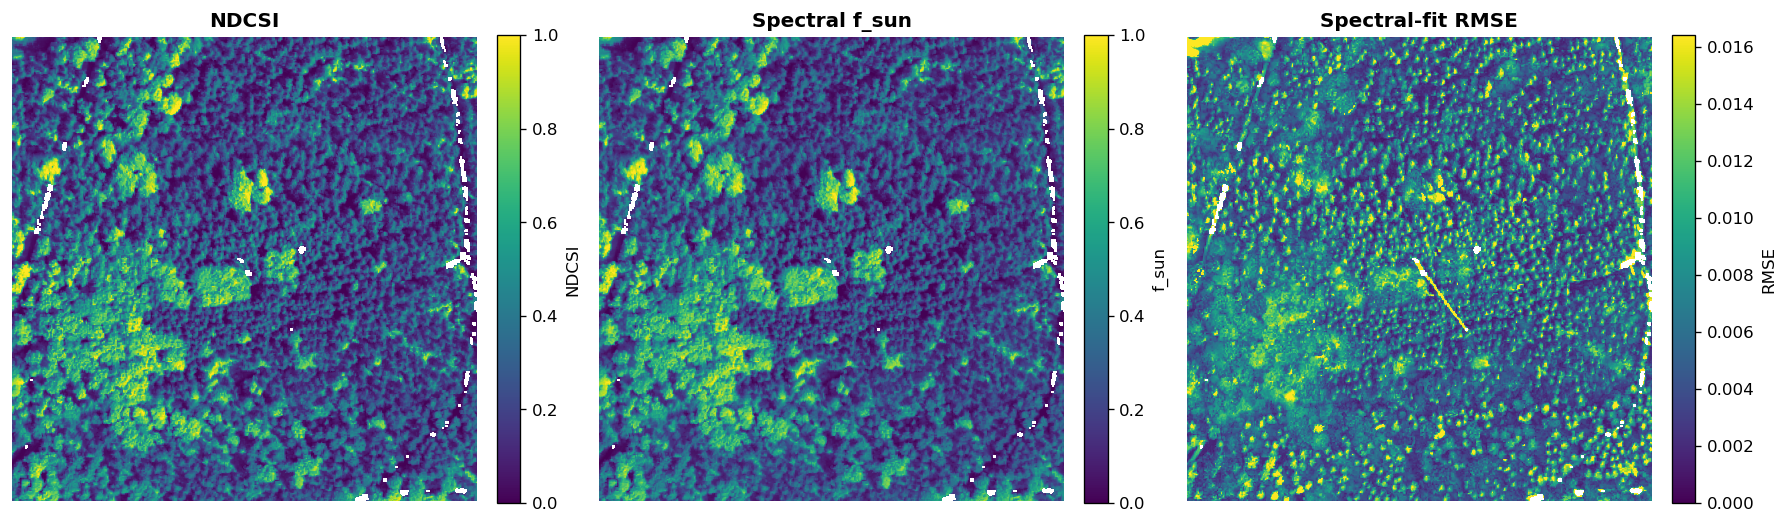

In [8]:
rmse_max = (
    np.nanpercentile(rmse, 98)
    if RMSE_DISPLAY_MAX is None and np.isfinite(rmse).any()
    else (RMSE_DISPLAY_MAX if RMSE_DISPLAY_MAX is not None else 1.0)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
plots = [
    (ndcsi, "NDCSI", 0, 1, "NDCSI"),
    (f_sun, "Spectral f_sun", 0, 1, "f_sun"),
    (rmse, "Spectral-fit RMSE", 0, rmse_max, "RMSE"),
]
for ax, (data, title, vmin, vmax, label) in zip(axes, plots):
    im = ax.imshow(data, cmap=MAP_CMAP, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, label=label, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(OUT_DIR / "illumination_diagnostics.png", bbox_inches="tight")
plt.show()